## Results Explorer
This notebook will take the .csv files from the data_analysis_main.py file, and plot graphs to analyse the residual and gini calculations (mean and individuals)

In [24]:
import pandas as pd
import os
import glob
import pathlib
from matplotlib import pyplot as plt
from data_analysis_main import sort_nicely

### Individual plots
1. Plot an agent's residual difference (the difference between their current residual and the previous one) on a violin graph
2. Plot an agent's residual (no difference) on a violin graph

In [25]:
# Note: anything that ends in violin is one that has individual data in it
# - individuals_difference is a residual difference compared to the previous residual
# - individuals is a residual only for a single agent
CUR_DIR = str(pathlib.Path(os.path.abspath(os.curdir)).parent) # Note, this does not include a trailing '/'
repo_root_csvs_dir = "/plots/SYNTH_vary_grp_fact/"
values_list = "pvs" # The values used in each residual calculation will be at the front of the file
# Find all .csvs and sort so order will be the same
ind_files = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals[!_]*")
ind_diff_files = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals_difference*")
sort_nicely(ind_files), sort_nicely(ind_diff_files)

print("ind_files are: ", ind_files)
# import each csv into a dataframe, and store in a dict = {baseline key: df, ...}
ind_dfs, ind_diff_dfs = {}, {}
for ind_file, ind_diff_file in zip(ind_files, ind_diff_files):
    baseline_name = ind_file.split("/")[-1].split("_")[2] # Because we sorted, ind_file and ind_diff_files will be equal
    baseline_name = baseline_name[11:-10]
    # Read CSV without treating first row as header
    ind_dfs[baseline_name] = pd.read_csv(ind_file, header=None, skiprows=1)
    ind_diff_dfs[baseline_name] = pd.read_csv(ind_diff_file, header=None, skiprows=1)
    # Assign column names (0, 1, 2, ...)
    ind_dfs[baseline_name].columns = range(len(ind_dfs[baseline_name].columns))
    ind_diff_dfs[baseline_name].columns = range(len(ind_diff_dfs[baseline_name].columns))
    # Remove the agent_id and the initial points (for ind_diff_dfs)
    ind_dfs[baseline_name].drop(0, axis=1, inplace=True)
    ind_diff_dfs[baseline_name].drop([0,1], axis=1, inplace=True)


ind_files are:  ['/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individuals1violin.csv', '/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individualsHCVAppviolin.csv', '/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individualsHCVAviolin.csv', '/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individualsSLMviolin.csv', '/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individualsTviolin.csv', '/home/ia23938/Documents/GitHub/HCVA-plus-plus/plots/SYNTH_vary_grp_fact/pvs_residuals_individualsinfviolin.csv']


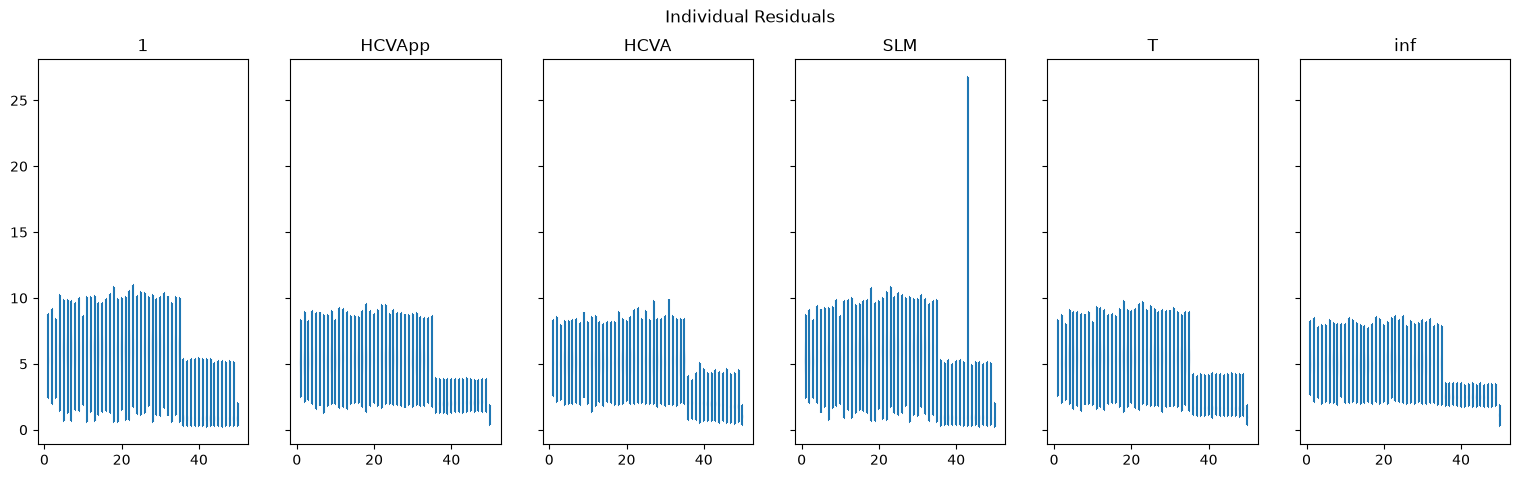

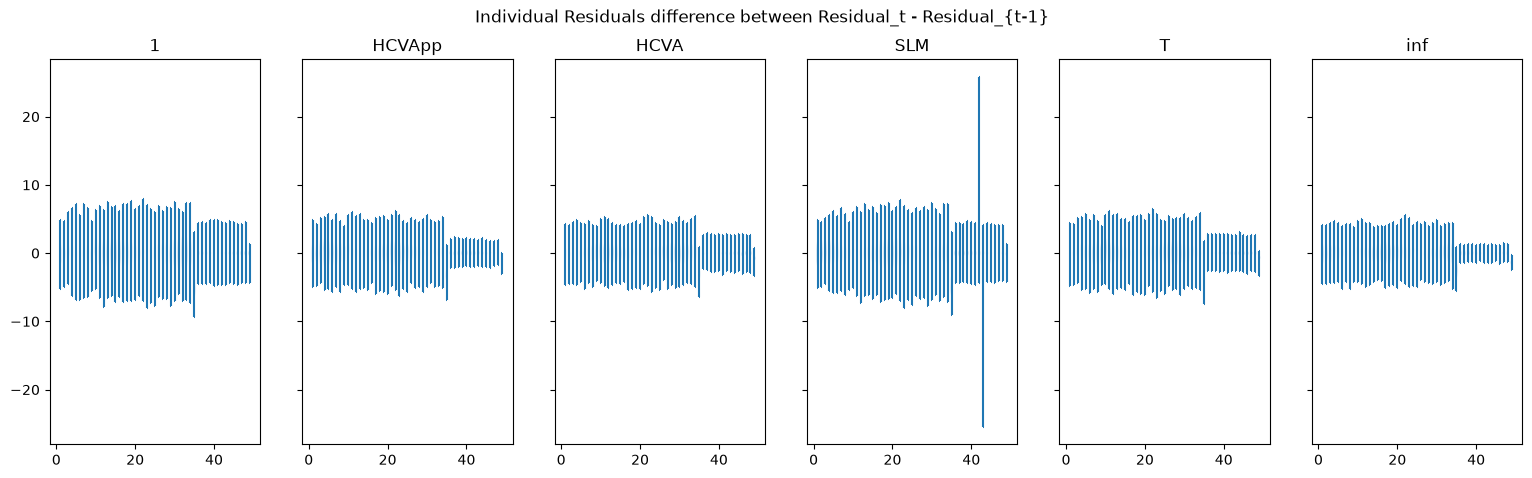

In [26]:
# Plot each row (where col[0] for each df is an ID) onto a violin plot. Overlay for each method and plot as a 3x2 grid
fig_ind, axes_ind = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
fig_ind.suptitle("Individual Residuals")
fig_ind_diff, axes_ind_dff = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
fig_ind_diff.suptitle("Individual Residuals difference between Residual_t - Residual_{t-1}")
for ax_ind, ax_ind_diff, key in zip(axes_ind.flatten(), axes_ind_dff.flatten(), ind_dfs.keys()):
    ax_ind.set_title(key)
    ax_ind_diff.set_title(key)
    ax_ind.violinplot(ind_dfs[key].values, showmeans=False, showmedians=False, showextrema=True)
    ax_ind_diff.violinplot(ind_diff_dfs[key].values, showmeans=False, showmedians=False, showextrema=True)
plt.show() # This plot shows a violin plot per time step (x), showing the individual agent data that has been averaged over 500 runs.

### Quartile Plots
3. Plot residual and residual differences as an upper or lower quartile of all agents. That means we can represent those who are always given poor residuals vs those that are given the best (even if the agent IDs input data characteristics are different at each time). 

### Group A or B?
4. Plot different colours for whether an agent is in group A or group B for the grp_fact experiment
5. Plot different colours for whether an agent's values are mostly neutral, or whether they are more extreme for mup_vamu experiment
6. Plot different colours for whether an agent's  
